In [26]:
import pandas as pd
from IPython.display import HTML

language_stats = pd.read_csv("language_stats.csv")
language_stats.head()

,game_language,game,model,experiment,instance,type,language,count
0,en,hot_air_balloon,deepseek-chat-v3.1-t1.0,air_balloon_survival_en_negotiation_hard,5,response,en,6
1,en,hot_air_balloon,deepseek-chat-v3.1-t1.0,air_balloon_survival_en_negotiation_hard,2,response,en,7
2,en,hot_air_balloon,deepseek-chat-v3.1-t1.0,air_balloon_survival_en_negotiation_hard,3,response,en,13
3,en,hot_air_balloon,deepseek-chat-v3.1-t1.0,air_balloon_survival_en_negotiation_hard,4,response,en,11
4,en,hot_air_balloon,deepseek-chat-v3.1-t1.0,air_balloon_survival_en_negotiation_hard,1,response,en,8


In [ ]:
# for each model, game_language, and type, sum up the counts of each language
language_summary = language_stats.groupby(["model", "game_language", "type", "language"]).sum().reset_index()
# drop game and experiment columns
language_summary = language_summary.drop(columns=["game", "experiment", "instance"])
# in 'model', remove the suffix after the last '-'
language_summary["model"] = language_summary["model"].apply(lambda x: "-".join(x.split("-")[:-1]))
# sort by model, game_language, type, language
language_summary = language_summary.sort_values(by=["model", "game_language", "type", "language"])

HTML(language_summary.to_html(index=False))

TypeError: unhashable type: 'list'

In [16]:
# split in two dfs: thinking and response
thinking_summary = language_summary[language_summary["type"] == "thinking"]
response_summary = language_summary[language_summary["type"] == "response"]
HTML(thinking_summary.to_html(index=False))

model,game_language,type,language,count
claude-sonnet-4-20250514-t0.0,en,thinking,en,1063
claude-sonnet-4-20250514-t1.0,de,thinking,de,936
claude-sonnet-4-20250514-t1.0,de,thinking,en,184
claude-sonnet-4-20250514-t1.0,it,thinking,en,175
claude-sonnet-4-20250514-t1.0,it,thinking,it,935
deepseek-r1-distill-llama-70b-t1.0,de,thinking,de,132
deepseek-r1-distill-llama-70b-t1.0,de,thinking,en,754
deepseek-r1-distill-llama-70b-t1.0,de,thinking,nl,1
deepseek-r1-distill-llama-70b-t1.0,de,thinking,ru,1
deepseek-r1-distill-llama-70b-t1.0,de,thinking,zh,4


In [17]:
# # for each model and game_language, add a row with the total count of all languages
# thinking_summary_total = thinking_summary.groupby(["model", "game_language"]).sum().reset_index()
# thinking_summary_total["language"] = "total"
# thinking_summary_total = thinking_summary_total[["model", "game_language", "language", "count", "type"]]
# thinking_summary_total["type"] = "thinking"
# thinking_summary = pd.concat([thinking_summary, thinking_summary_total], ignore_index=True)
# thinking_summary = thinking_summary.sort_values(by=["model", "game_language", "language"])
# HTML(thinking_summary.to_html(index=False))

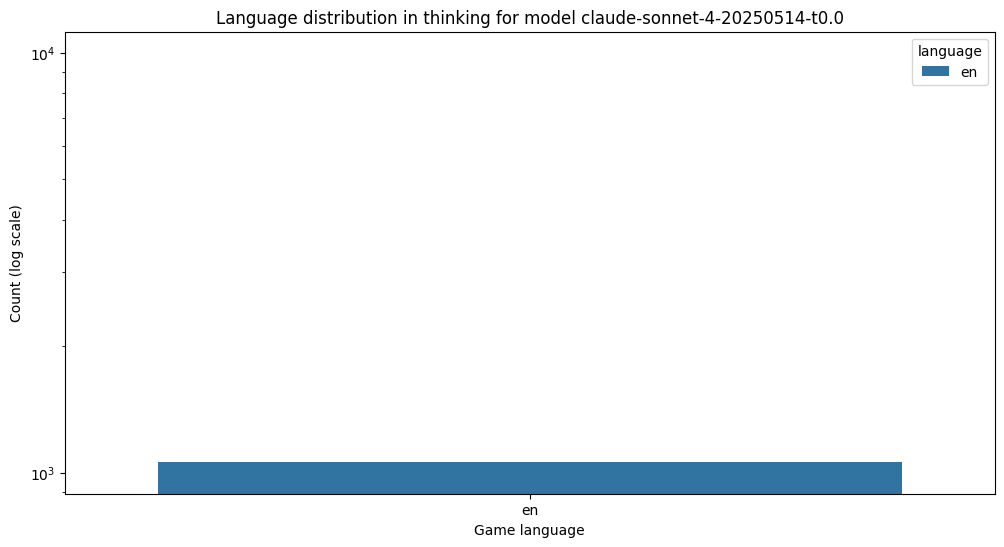

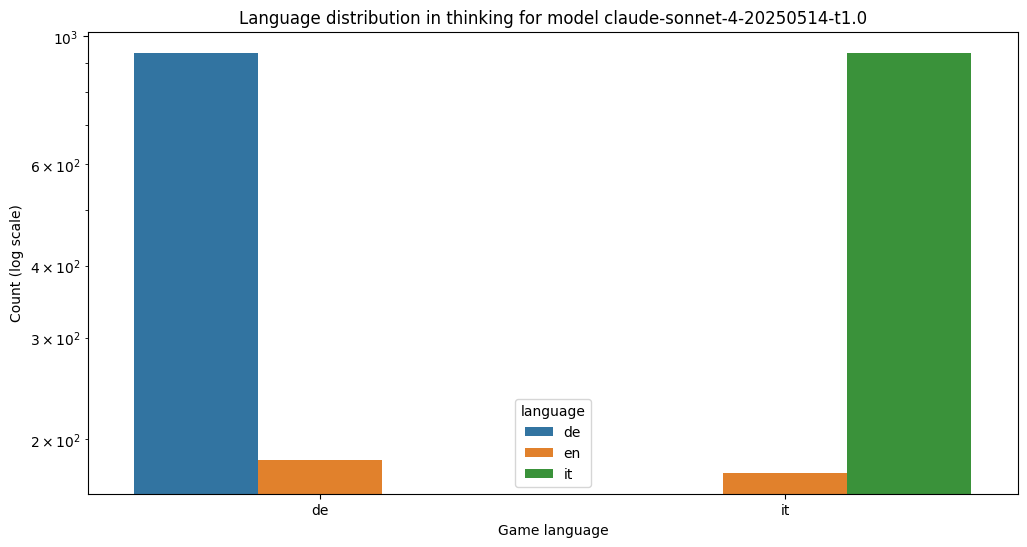

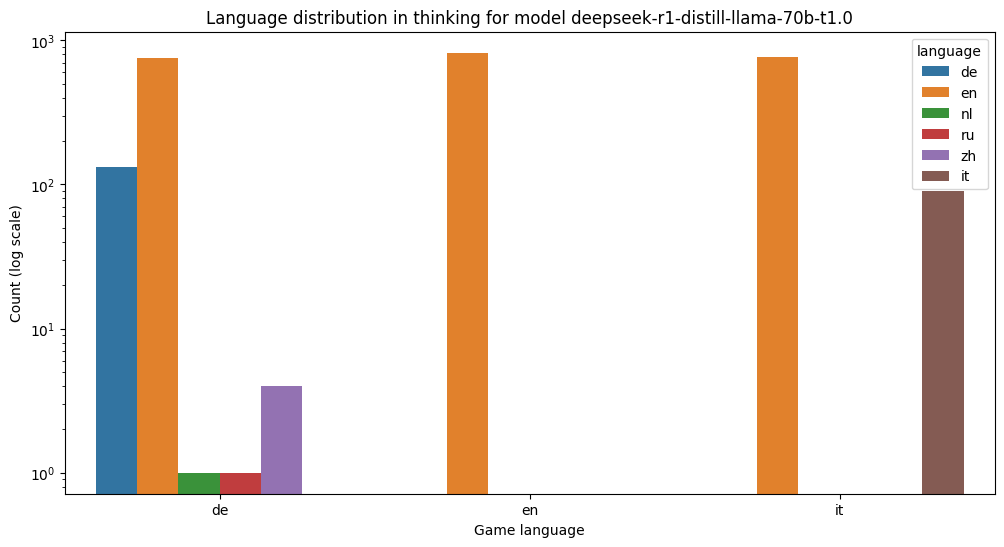

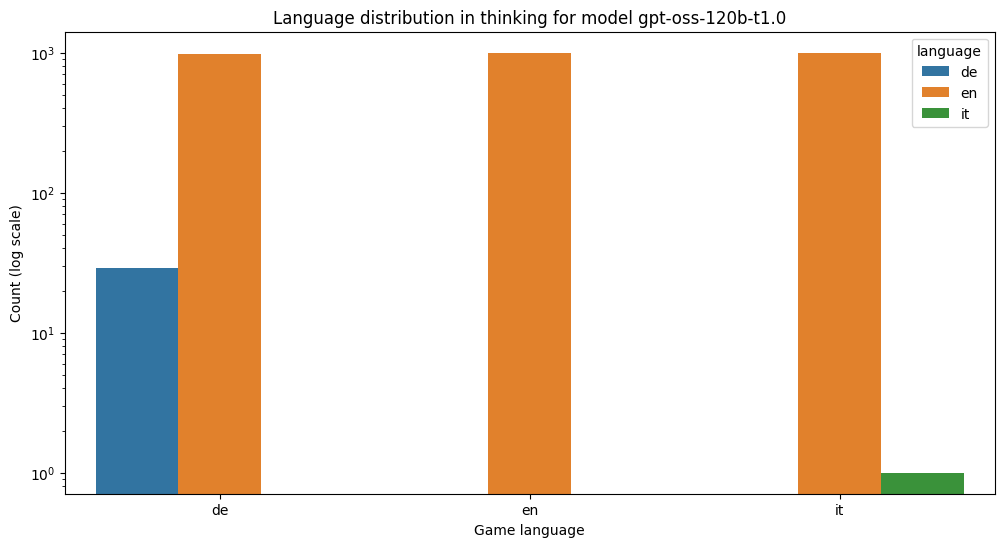

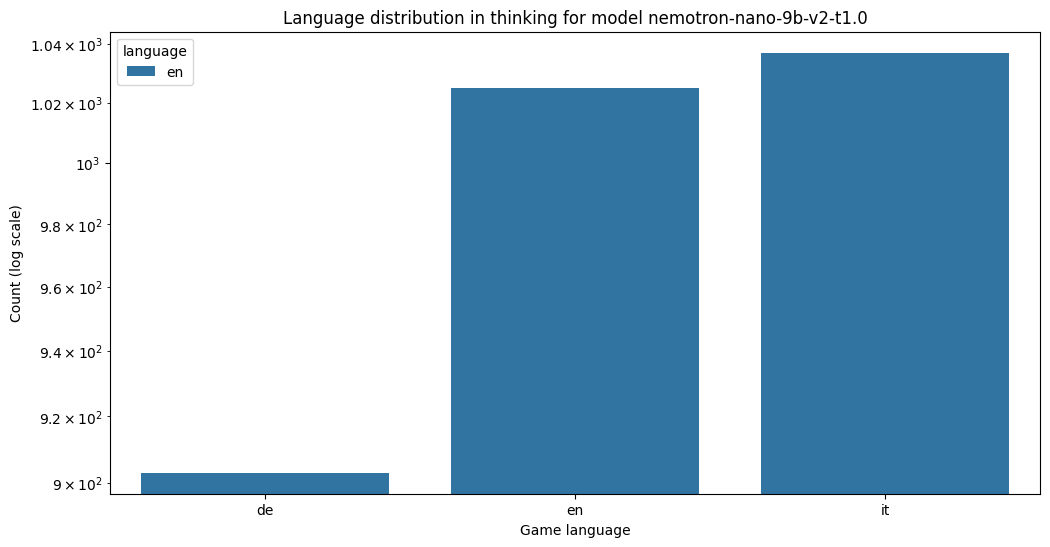

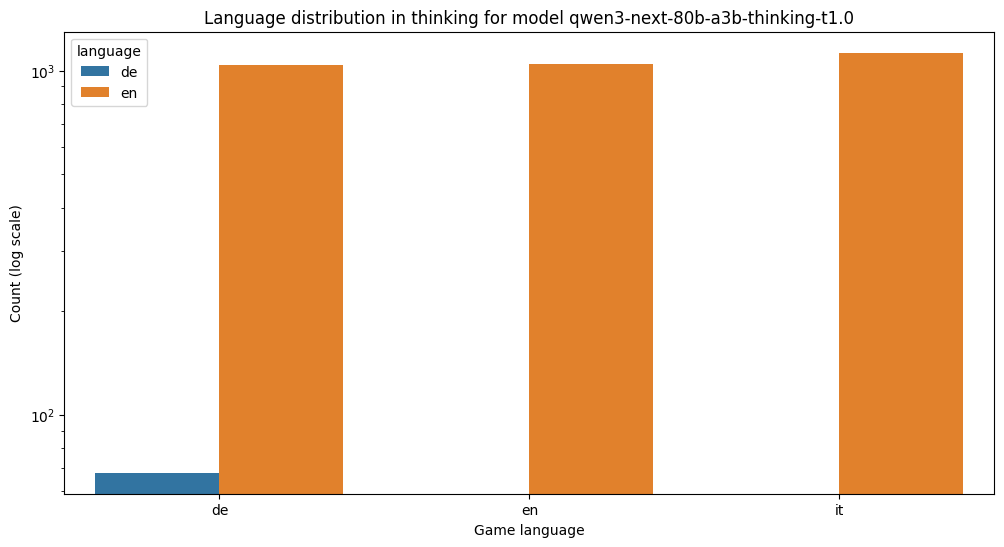

In [21]:
# plot the thinking summary as a bar plot with seaborn
import seaborn as sns
import matplotlib.pyplot as plt
for model in thinking_summary["model"].unique():
    model_summary = thinking_summary[thinking_summary["model"] == model]
    plt.figure(figsize=(12, 6))
    sns.barplot(data=model_summary, x="game_language", y="count", hue="language")
    plt.yscale("log")
    plt.xlabel("Game language")
    plt.ylabel("Count (log scale)")
    plt.title(f"Language distribution in thinking for model {model}")
    plt.show()
# plt.figure(figsize=(12, 6))
# sns.barplot(data=thinking_summary, x="game_language", y="count", hue="language")
# # logarithmic y scale
# plt.yscale("log")
# plt.xlabel("Game language")
# plt.ylabel("Count (log scale)")
# plt.title("Language distribution in thinking")
# plt.show()

In [19]:
HTML(response_summary.to_html(index=False))

model,game_language,type,language,count
claude-sonnet-4-20250514-t0.0,en,response,en,674
claude-sonnet-4-20250514-t1.0,de,response,de,1061
claude-sonnet-4-20250514-t1.0,it,response,it,734
deepseek-chat-v3.1-t1.0,de,response,de,1377
deepseek-chat-v3.1-t1.0,de,response,en,6
deepseek-chat-v3.1-t1.0,en,response,en,734
deepseek-chat-v3.1-t1.0,it,response,en,7
deepseek-chat-v3.1-t1.0,it,response,it,963
deepseek-r1-distill-llama-70b-t1.0,de,response,de,770
deepseek-r1-distill-llama-70b-t1.0,de,response,en,43
